# Data Loading

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
# Vizualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Imupter
from sklearn.impute import SimpleImputer

# Train-Validation Split
from sklearn.model_selection import train_test_split

#Vectorizer
from sklearn.feature_extraction.text import TfidfVectorizer

# Scaler and Encoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder

#Matrix operations
from scipy.sparse import hstack, vstack, csr_matrix

# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score

# Evaluation Metric
from sklearn.metrics import f1_score

In [4]:
# Models

from sklearn.dummy import DummyClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
import lightgbm as lgb
from xgboost import XGBClassifier

In [5]:
# Accessing Data files
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_sub = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

# Exploratory Data Analysis

## Train data

In [6]:
#Checking the dataframe information about the data
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [7]:
# Checking Shape of the data
train.shape

(198000, 15)

In [8]:
# Checking columns of the data
train.columns

Index(['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3',
       'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender',
       'disability', 'comment', 'label'],
      dtype='object')

In [9]:
# Checking the contents of the file
train.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


## Test Data

In [10]:
test.info()
test.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


(102000, 14)

In [11]:
test.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment
0,2024-02-08 13:13:27.998156+00:00,72,2,0,0,4,1,0,10,NaN,NaN,NaN,False,Canada is being run by someone with the mental...
1,2024-03-01 23:33:25.547123+00:00,123,0,0,0,0,0,0,10,NaN,NaN,NaN,False,And your comment is left-wing drivel
2,2024-02-09 21:52:48.426303+00:00,120,0,0,0,3,0,0,4,NaN,NaN,NaN,False,http://talkingpointsmemo..com/dc/special-couns...
3,2024-02-17 03:43:02.980294+00:00,123,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Trump jl Blames: The Secret Service, James Com..."
4,2024-04-24 02:27:57.145155+00:00,123,0,0,0,0,0,0,11,NaN,NaN,NaN,False,It was hard enough to get the stench out of th...


## Checking Duplicates

In [12]:
train = train.drop_duplicates()
train.shape
# Since the shape remains unchanged, there are no duplicate values

(198000, 15)

## Descriptive Statistics

In [13]:
train.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [14]:
#Descriptive statistics of the catagorical data
train.describe(include="object")

,created_date,race,religion,gender,comment
count,198000,52577,52577,52577,197999
unique,197996,6,8,5,197842
top,2022-05-06 20:47:06.726636+00:00,none,none,none,Exactly..
freq,2,39682,38249,36161,8


## Vizualization

### Countplot for Label column

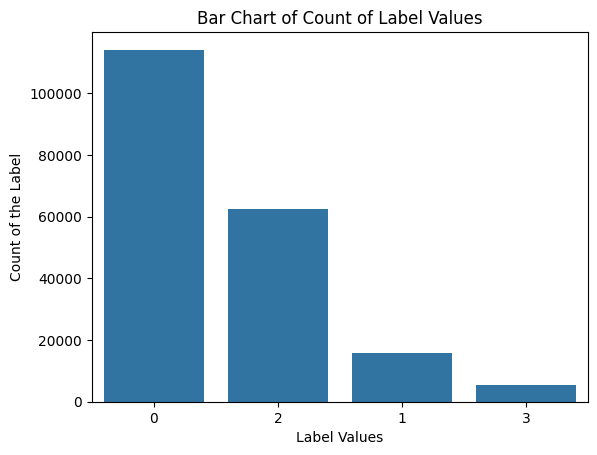

label
0    114173
2     62440
1     15918
3      5469
Name: count, dtype: int64


In [15]:
# Bar chart of count of label values in the train dataset
sns.countplot(x="label", data=train, order=train["label"].value_counts().index)
plt.title("Bar Chart of Count of Label Values")
plt.xlabel("Label Values")
plt.ylabel("Count of the Label")
plt.show()
print(train['label'].value_counts())

#### Observations
1. There are 4 unique classes (0,1,2,3)
2. Class 0 have the highest count followed by class 2, class 1 and class 3 with the lowest

### Correlation Heatmap for Numeric values

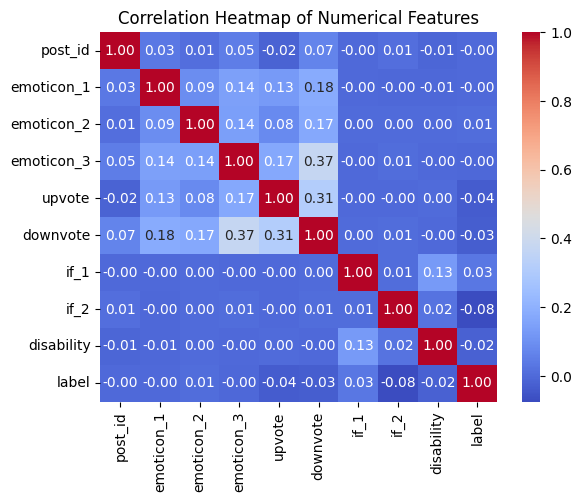

In [16]:
temp_train = train.copy()
temp_train['label'], uniques = pd.factorize(temp_train['label'])
#Factorize translates text labels into numbers (0,1,2,3) so the mathematical correlation function can process them.
correlation_matrix = temp_train.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

#### Observations
1. Downvote and Emoticon_3 have a positive correlation (0.37). Shows that Emoticon_3 is generally used negatively alongside downvotes.
2. Upvote and Downvote have a positive correlation (0.31). It shows that comments with upvotes also tend to have proportional amount of downvotes.
3. Downvote and Emoticon_1 have a weak positive correlation (0.18). Shows that Emoticon_1 is sometimes used alongside the downvote.
4. Upvote and Emoticon_3, as well as Downvote and Emoticon_2, share a weak positive correlation (0.17). It shows that Emoticon_3 is sometimes used with upvotes and Emoticon_2 is sometimes used with Downvote
5. Emoticon_3 and Emoticon_1, as well as Emoticon_3 and Emoticon_2, share a weak positive correlation (0.14). It shows that Emoticon_3 and Emoticon_1 and Emoticon_3 and Emoticon_2 is used together sometimes. 
6. If_1 and Disability have a weak positive correlation (0.13). It shows that the Internal feature one is used for people with disability.


### Box plot of numeric features

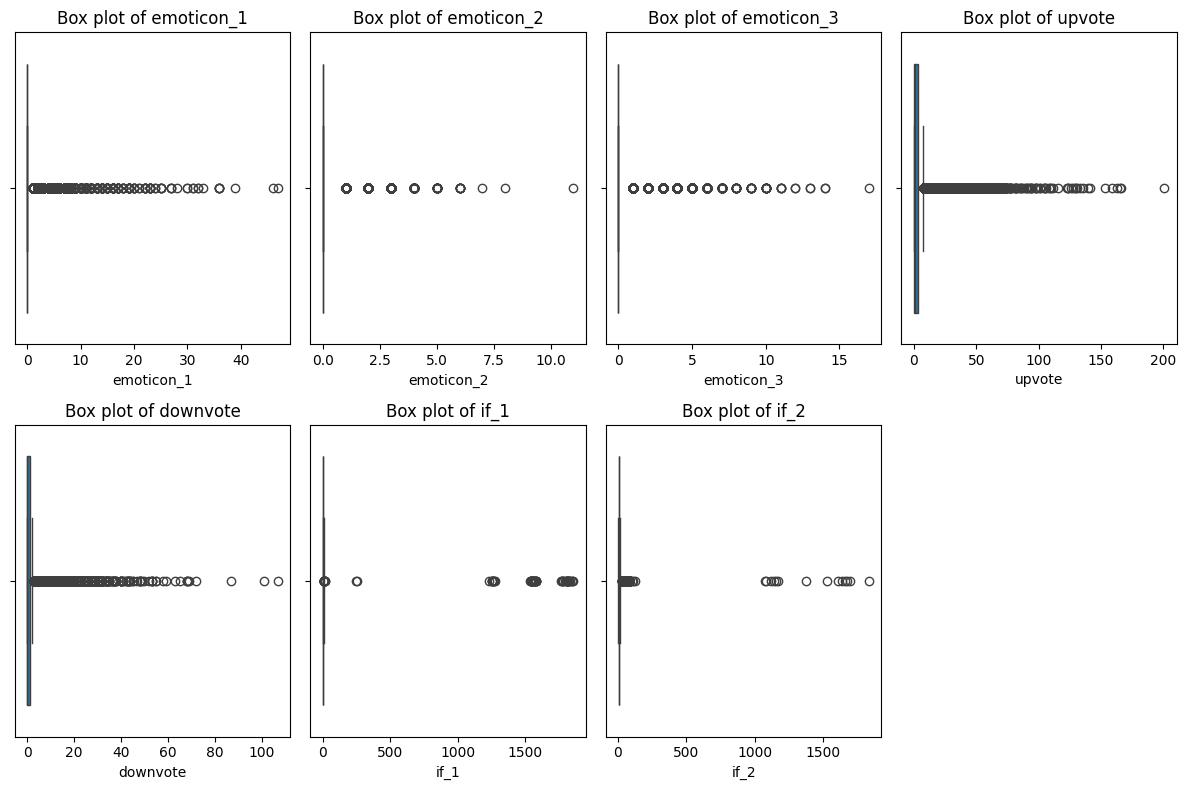

In [17]:
num_cols = train.select_dtypes(include="number").columns.drop(["label", "post_id"])
plt.figure(figsize=(12, 8))
for i, col in enumerate(num_cols,1):
    plt.subplot(2, 4, i)
    sns.boxplot(x=train[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

#### Observation

In [18]:
summary_table = pd.DataFrame({
    "Minimum": train[num_cols].min(),
    "25th Percentile": train[num_cols].quantile(0.25),
    "50th Percentile": train[num_cols].quantile(0.50),
    "75th Percentile": train[num_cols].quantile(0.75),
    "Maximum": train[num_cols].max()
})

summary_table["IQR"] = (
    summary_table["75th Percentile"] - summary_table["25th Percentile"]
)
summary_table["Range"] = (
    summary_table["Maximum"] - summary_table["Minimum"]
)

summary_table.transpose() 

,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2
Minimum,0.0,0.0,0.0,0.0,0.0,0.0,3.0
25th Percentile,0.0,0.0,0.0,0.0,0.0,0.0,4.0
50th Percentile,0.0,0.0,0.0,1.0,0.0,0.0,6.0
75th Percentile,0.0,0.0,0.0,3.0,1.0,4.0,10.0
Maximum,47.0,11.0,17.0,201.0,107.0,1860.0,1833.0
IQR,0.0,0.0,0.0,3.0,1.0,4.0,6.0
Range,47.0,11.0,17.0,201.0,107.0,1860.0,1830.0


The above code shows the Minimum value, 25th Percentile, 50th Percentile, 75th Percentile, Maximum value, Inter quartile range and range of the numeric columns in train dataset, visualised through box plots in chart above

### Line Chart to check upload activity

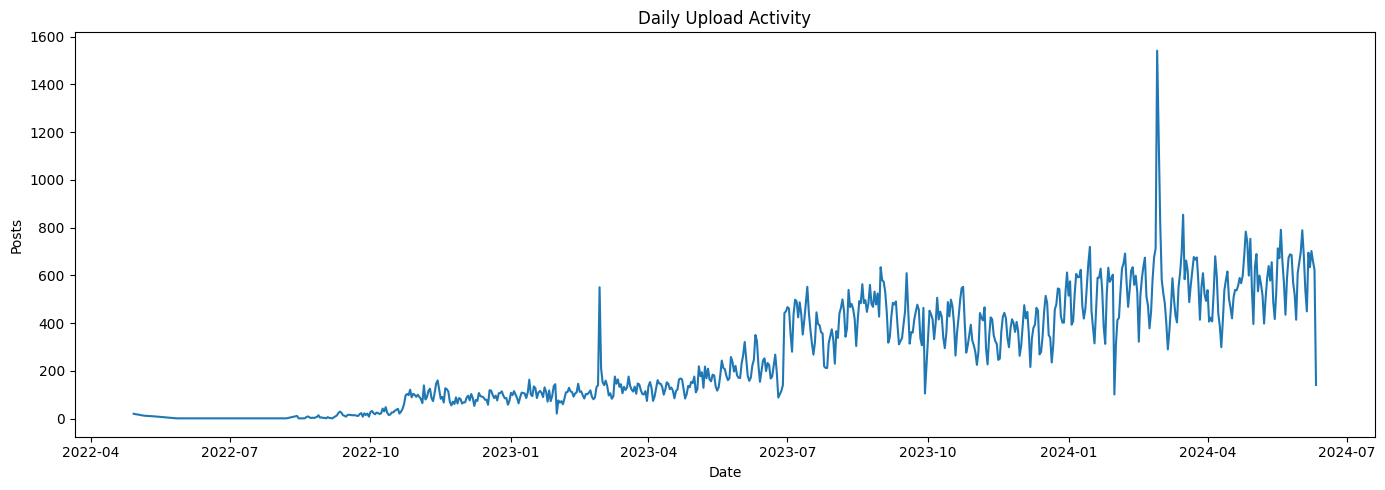

In [19]:
temp_train["created_date"] = pd.to_datetime(temp_train["created_date"])

daily_upload_activity = temp_train.groupby(temp_train['created_date'].dt.date).size()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_upload_activity.index, daily_upload_activity.values)

ax.set_title('Daily Upload Activity')
ax.set_xlabel('Date')
ax.set_ylabel('Posts')
plt.tight_layout()
plt.show()

#### Observation
1. We can see two sharp peaks near March 2023 and March 2024, showing that some activites in March increases upload activity
2. We can see the rise in posts on the platform near July 2023
3. We can see several dips in upload activity, approximately during October 2023, February 2024 and June 2024

### Label distribution for Race, Religion and Gender

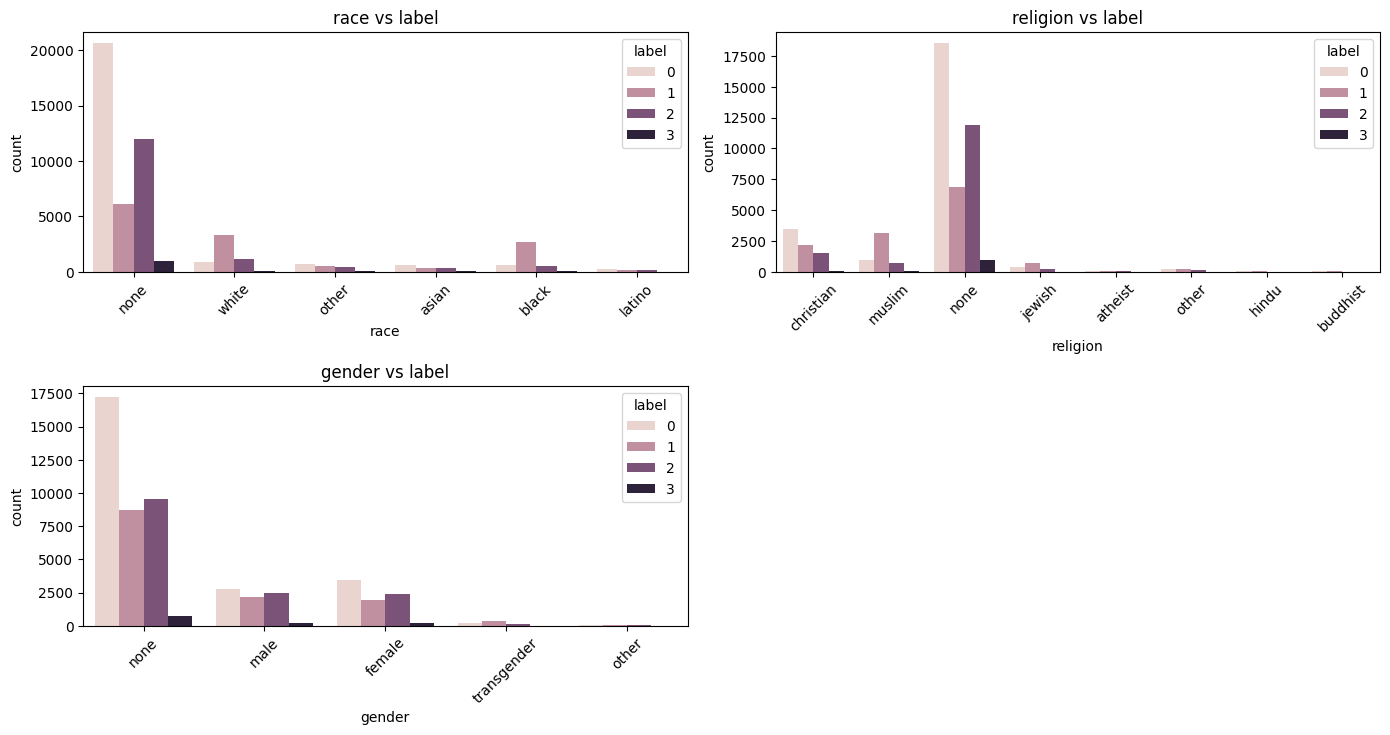

In [20]:
cat_cols = train.select_dtypes(include=['object', 'category']).drop(columns=["comment","created_date"])
plt.figure(figsize=(14, 10))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=col, hue='label', data=train)
    plt.title(f'{col} vs label')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


#### Observation

In [21]:
summary_table_race = pd.crosstab(train['label'], train['race'])
summary_table_religion = pd.crosstab(train["label"], train['religion'])
summary_table_gender = pd.crosstab(train["label"], train['gender'])
summary_table_race, summary_table_religion, summary_table_gender

(race   asian  black  latino   none  other  white
 label                                           
 0        570    608     274  20606    676    923
 1        364   2679     200   6138    489   3338
 2        305    555     143  11973    453   1165
 3         24     27       6    965     36     60,
 religion  atheist  buddhist  christian  hindu  jewish  muslim   none  other
 label                                                                      
 0              85        43       3460     50     348     965  18524    182
 1              71        39       2160     29     673    3134   6883    219
 2              57        17       1498     17     210     732  11928    135
 3               6         1         73      1      13      99    914     11,
 gender  female  male   none  other  transgender
 label                                          
 0         3449  2758  17201     75          174
 1         1965  2142   8694     79          328
 2         2425  2475   9529     50     

The above code shows the count of each unique value of the categorical data in train dataset accoriding to their label, visualized in graph above

## Handling Null Values

In [22]:
print(train.isnull().sum(), "\n\n" ,test.isnull().sum())

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64 

 created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


Since there is one missing value in "comment" we can remove it. 

In [23]:
train = train.dropna(subset=["comment"]) #Dropping the case and saving the change in dataset
train.shape

(197999, 15)

Since there are many rows in "race", "religion" and "gender", and since there is no other way to fill the information, we will impute it as "Not Known". 
Since the imputed value is a string constant, it will not cause data leakage. 

In [24]:
cat_col = ['race', 'religion', 'gender']
train[cat_col] = train[cat_col].fillna("Not Known")
test[cat_col] = test[cat_col].fillna("Not Known")

train.isna().sum(), test.isna().sum()

(created_date    0
 post_id         0
 emoticon_1      0
 emoticon_2      0
 emoticon_3      0
 upvote          0
 downvote        0
 if_1            0
 if_2            0
 race            0
 religion        0
 gender          0
 disability      0
 comment         0
 label           0
 dtype: int64,
 created_date    0
 post_id         0
 emoticon_1      0
 emoticon_2      0
 emoticon_3      0
 upvote          0
 downvote        0
 if_1            0
 if_2            0
 race            0
 religion        0
 gender          0
 disability      0
 comment         0
 dtype: int64)

## Outliers Detection

In [25]:
num_col = train.select_dtypes(include='number').columns.drop(['label','post_id'])
num_col

Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1',
       'if_2'],
      dtype='object')

In [26]:
q1 = train[num_col].quantile(0.25)
q3 = train[num_col].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

outlier = (train[num_col] < lower_bound) | (train[num_col] > upper_bound)

outlier_count = outlier.sum()

outlier_pct = (outlier_count / len(train)) * 100

outlier_summary = pd.DataFrame({
    "Outlier %":     outlier_pct.round(2)
})
outlier_summary = outlier_summary.sort_values("Outlier %", ascending = False)
outlier_summary.index.name = "Feature"

print(outlier_summary)

            Outlier %
Feature              
emoticon_1      14.61
upvote           8.74
emoticon_3       8.67
downvote         7.66
emoticon_2       4.10
if_2             1.98
if_1             0.04


# Train - Validation Split

In [27]:
#Spliting train.csv into train and test data
X = train.drop(columns=['label'], axis=1)
y = train['label']
X_train, X_val, y_train , y_val = train_test_split(X, y, random_state=42, test_size=0.15, stratify=y)

Stratified is used here because the labels in the dataset are not distributed equally, thus, "stratify=y" ensures that while splitting the dataset into train and test, class proportion in both train and test is roughly same.

In [28]:
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(168299, 14) (29700, 14) (168299,) (29700,)


# Data Preprocessing

## TF-IDF Vectorization

In [29]:
test_copy = test.copy()

In [30]:
tfidf = TfidfVectorizer(analyzer = 'word', max_df = 0.80, min_df = 0.0009, sublinear_tf=True , stop_words = 'english', ngram_range=(1,2), token_pattern=r'(?u)\b[a-zA-Z]{2,}\b') #Calling Tdidf Vectorizer
tfidf_train = tfidf.fit_transform(X_train["comment"]) #fitting the tdidf vectorizer (creates a list of unique words in comment)
feature_names = tfidf.get_feature_names_out()
feature_names, feature_names.shape

(array(['abandoned', 'abiding', 'ability', ..., 'zero', 'zone', 'zuma'],
       dtype=object),
 (4296,))

In [31]:
# Transforming the matrix into tfidf matrix
tfidf_val = tfidf.transform(X_val["comment"])
tfidf_test = tfidf.transform(test_copy['comment'])

#### Parameters of TfidfVectorizer
1. analyzer = 'word' : It tells whether the feature should be made of word or character n-grams, where we are taking it as word.
2. ngram_range = (1,2) : Is is the lower and upper boundary of the range of n-values for different n-grams to be extracted. (1, 2) means unigrams and bigrams.
3. stop_words = 'english' : Takes only those words present in english vocabulary
4. max_df = 0.8 : Sets a "maximum document frequency" threshold. The vectorizer will ignore any term that appears in more than 80% of the documents, that is the word appearing in roughly 80% of cases is discareded as it is very common. 
5. min_df = 0.0009 : Sets a "minimum document frequency" threshold. The vectorizer will ignore any term that appears in fewer than 0.09% of the rows 
6. sublinear_tf=True : Applies logarithmic scaling to the term frequency. Instead of using the raw count (tf), it transforms it using 1 + log(tf). This dampens the impact of high frequency counts.
7. token_pattern=r'(?u)\b[a-zA-Z]{2,}\b' :
   - (?u): Enables Unicode matching.
   - \b: Looks for clear word boundaries
   - [a-zA-Z]{2,}: Mandates that tokens must be composed entirely of alphabetical letters (no numbers, no special characters) and must be at least 2 characters long.

## Feature Engineering

In [32]:
# created_date column : Converting into hour, weekday, month and year

# Train
X_train["created_date"] = pd.to_datetime(X_train["created_date"])
X_train["day"] = X_train["created_date"].dt.day
X_train["month"] = X_train["created_date"].dt.month
X_train["year"] = X_train["created_date"].dt.year
X_train = X_train.drop(columns='created_date')

# Val
X_val["created_date"] = pd.to_datetime(X_val["created_date"])
X_val["day"] = X_val["created_date"].dt.day
X_val["month"] = X_val["created_date"].dt.month
X_val["year"] = X_val["created_date"].dt.year
X_val = X_val.drop(columns='created_date')

# Test
test_copy["created_date"] = pd.to_datetime(test_copy["created_date"])
test_copy["day"] = test_copy["created_date"].dt.day
test_copy["month"] = test_copy["created_date"].dt.month
test_copy["year"] = test_copy["created_date"].dt.year
test_copy = test_copy.drop(columns='created_date')
X_train.columns, X_val.columns, test_copy.columns

(Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote',
        'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability',
        'comment', 'day', 'month', 'year'],
       dtype='object'),
 Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote',
        'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability',
        'comment', 'day', 'month', 'year'],
       dtype='object'),
 Index(['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote',
        'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability',
        'comment', 'day', 'month', 'year'],
       dtype='object'))

In [33]:
# post_id column : dropping the identifier as it will not provide value in ML algorithms
X_train = X_train.drop(columns=['post_id'])
X_val = X_val.drop(columns=['post_id'])
test_copy = test_copy.drop(columns=['post_id'])
X_train.columns, X_val.columns, test_copy.columns

(Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1',
        'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'day',
        'month', 'year'],
       dtype='object'),
 Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1',
        'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'day',
        'month', 'year'],
       dtype='object'),
 Index(['emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1',
        'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'day',
        'month', 'year'],
       dtype='object'))

In [34]:
#disability : Converting Boolean into Binary
X_train["disability"] = X_train["disability"].astype(int)
X_val["disability"] = X_val["disability"].astype(int)
test_copy["disability"] = test_copy["disability"].astype(int)

In [35]:
X_train["vote_ratio"] = X_train['upvote'] / (X_train['upvote'] + X_train['downvote'] + 1)
X_val["vote_ratio"] = X_val['upvote'] / (X_val['upvote'] + X_val['downvote'] + 1)
test_copy["vote_ratio"] = test_copy['upvote'] / (test_copy['upvote'] + test_copy['downvote'] + 1)

In [36]:
X_train['net_votes'] = np.sign(X_train['upvote']- X_train['downvote']) * np.log1p(np.abs(X_train['upvote']- X_train['downvote']))
X_val['net_votes'] = np.sign(X_val['upvote']- X_val['downvote']) * np.log1p(np.abs(X_val['upvote']- X_val['downvote']))
test_copy['net_votes'] = np.sign(test_copy['upvote']- test_copy['downvote']) * np.log1p(np.abs(test_copy['upvote']- test_copy['downvote']))

In [37]:
# Dropping Comment column
X_train = X_train.drop(columns=["comment"])
X_val = X_val.drop(columns=["comment"])
test_copy = test_copy.drop(columns=["comment"])

### One Hot Encoding

In [38]:
#gender, race, religion : One Hot Encoding the String labels
cat_cols = ["gender", "race", "religion"]

In [39]:
ohe = OneHotEncoder(sparse_output=True, handle_unknown="ignore")
X_train_cat = ohe.fit_transform(X_train[["gender","race","religion"]])
X_val_cat = ohe.transform(X_val[["gender","race","religion"]])
test_copy_cat = ohe.transform(test_copy[["gender","race","religion"]])

In [40]:
X_train = X_train.drop(columns=cat_cols)
X_val = X_val.drop(columns=cat_cols)
test_copy = test_copy.drop(columns=cat_cols)

In [41]:
# Combine numeric features (converted to sparse) with TF-IDF text features into a single sparse matrix.
X_train_csr = hstack([csr_matrix(tfidf_train)])
X_val_csr = hstack([csr_matrix(tfidf_val)])
test_copy_csr = hstack([csr_matrix(tfidf_test)])

#### Feature Engineering Explaination 
There are three blocks now:
1. X_train : Has all the numerical features.
2. X_train_cat : Has One hot encoded features (gender, religion, race).
3. X_train_csr : A compressed sparse matrix which stores the TF-IDF text features

## Outlier Damping (Log Transform)

In [42]:
# Seperating "disability" column since it is a boolean. 
X_train_dis_vote = X_train[['disability', 'net_votes']]
X_val_dis_vote   = X_val[['disability', 'net_votes']]
test_copy_dis_vote = test_copy[['disability', 'net_votes']]

X_train = X_train.drop(columns=['disability', 'net_votes'])
X_val   = X_val.drop(columns=['disability', 'net_votes'])
test_copy = test_copy.drop(columns=['disability', 'net_votes'])

X_train_dis_vote   = csr_matrix(X_train_dis_vote.values)
X_val_dis_vote     = csr_matrix(X_val_dis_vote.values)
test_copy_dis_vote = csr_matrix(test_copy_dis_vote.values)

In [43]:
# Using Log Transform to handle Outliers in X_train, X_val and test_copy
X_train = np.log1p(X_train)
X_val = np.log1p(X_val)
test_copy = np.log1p(test_copy)

## Scaling

### Min Max Scaling:

#### **Formula:**

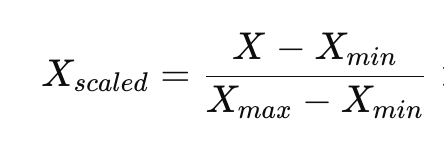

Here,
* X = Datapoint to be scaled
* X_min = Minimum value from the whole dataset
* X_max = Maximum value from the whole dataset

In [44]:
min_max = MinMaxScaler()
X_train_minmax = min_max.fit_transform(X_train)
X_val_minmax = min_max.transform(X_val)
test_copy_minmax = min_max.transform(test_copy)

### Standard Scaler
#### **Formula**
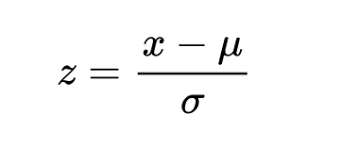

Here,
*  x = The datapoint to be scaled
*  μ = The mean of the whole dataset
*  σ = The Varience of the whole dataset

In [45]:
scaler = StandardScaler()
X_train_stdscl = scaler.fit_transform(X_train)
X_val_stdscl = scaler.transform(X_val)
test_copy_stdscl = scaler.transform(test_copy)

## Integration

In [46]:
# Append encoded categorical features (and any remaining features) to build the final combined feature matrix.
X_train_mm = hstack([X_train_minmax,X_train_dis_vote, X_train_cat, X_train_csr]).tocsr()
X_val_mm = hstack([X_val_minmax,X_val_dis_vote, X_val_cat, X_val_csr]).tocsr()
test_copy_mm = hstack([test_copy_minmax, test_copy_dis_vote, test_copy_cat, test_copy_csr]).tocsr()

In [47]:
X_train_ss = hstack([X_train_stdscl, X_train_dis_vote, X_train_cat, X_train_csr]).tocsr()
X_val_ss = hstack([X_val_stdscl, X_val_dis_vote, X_val_cat, X_val_csr]).tocsr()
test_copy_ss = hstack([test_copy_stdscl, test_copy_dis_vote, test_copy_cat, test_copy_csr]).tocsr()

In [48]:
train_mm = vstack([X_train_mm, X_val_mm]).tocsr()
train_ss = vstack([X_train_ss, X_val_ss]).tocsr()
y_full_train = np.concatenate([y_train, y_val])

In [49]:
X_train_mm.shape, X_val_mm.shape, test_copy_mm.shape

((168299, 4331), (29700, 4331), (102000, 4331))

In [50]:
train_mm.shape, train_ss.shape, y_full_train.shape

((197999, 4331), (197999, 4331), (197999,))

# Baseline Model : Dummy Classifier

In [51]:
# X_train = train.drop(columns=["label"])
# Y_train = train["label"]

In [52]:
# dummy = DummyClassifier(strategy="most_frequent")
# dummy.fit(X_train,Y_train)

In [53]:
# preds = dummy.predict(test)
# preds

# Multinomial Naive Bayes model

In [54]:
# Min_max scaled version
# mnb = MultinomialNB(random_state=42)
# mnb.fit(abs(X_train_mm), y_train)

In [55]:
# score_mnb_mm = mnb.predict(X_val_mm)
# f1 = f1_score(y_val, score_mnb_mm, average='macro')
# print("F1 Macro:", f1)

In [56]:
#Standard Scaler
# X_train_ss = abs(X_train_ss)
# X_val_ss = abs(X_val_ss)
# mnb_ss = MultinomialNB()
# mnb_ss.fit(X_train_ss, y_train)

In [57]:
# score_mnb_ss = mnb.predict(X_val_ss)
# f1 = f1_score(y_val, score_mnb_ss, average='macro')
# print("F1 Macro:", f1)

### Hyperparameter tuning

In [58]:
# Min-max
# mnb_new = MultinomialNB()
# param_dist = {
#     "alpha" : [0.01,0.1, 0.5, 1,10]
# }

# grid_search = GridSearchCV(
#     estimator = mnb_new,
#     param_grid = param_dist,
#     cv = 3,
#     scoring = 'f1_macro',
#     n_jobs = -1,
#     verbose = 2
# )

In [59]:
# grid_search.fit(abs(X_train_mm), y_train)
# print("Best parameters: ", grid_search.best_params_)
# print("F1 Score: ", grid_search.best_score_)

In [60]:
# Score on Validation set

# best_mnb = grid_search.best_estimator_
# y_pred = best_mnb.predict(abs(X_val_mm))
# f1 = f1_score(y_val, y_pred, average='macro')
# print("F1 Score: ", f1)

### Prediction

In [61]:
# mnb_test = MultinomialNB(alpha=0.1)
# mnb_test.fit(abs(train_mm), y_full_train)
# Score: 0.60098

In [62]:
# mnb_preds = mnb_test.predict(test_copy_mm)
# mnb_preds

# Random Forest Model

In [63]:
# rf = RandomForestClassifier()

In [64]:
#min-max

# rf.fit(X_train_mm, y_train)
# score_rf_mm = rf.predict(X_val_mm)
# f1 = f1_score(y_val, score_rf_mm, average='macro')
# print("F1:", f1)

In [65]:
# Standard scaler

# rf.fit(X_train_ss, y_train)
# score_rf_ss = rf.predict(X_val_ss)
# f1 = f1_score(y_val,score_rf_ss, average='macro')
# print("F1:", f1)

### Hyperparameter Tuning

In [66]:
# rf_new = RandomForestClassifier()
# param_dist = {
#     "n_estimators": [50, 200],
#     "max_depth": [10, 15],
#     "min_samples_leaf": [2, 3],
#     "min_samples_split": [3, 5]
# }
# random_search = RandomizedSearchCV(
#     estimator=rf_new,
#     param_grid=param_dist,
#     cv=3,
#     scoring="f1_macro",
#     n_jobs=-1,
#     random_state= 42,
#     n_iter = 8
# )

In [67]:
# random_search.fit(X_train_ss, y_train)
# print("Best parameters:", random_search.best_params_)
# print("Best CV F1:", random_search.best_score_)

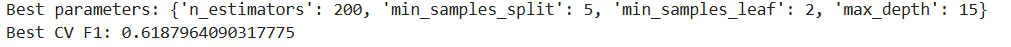

In [68]:
# Score on Validation set

# best_rf = random_search.best_estimator_
# y_pred = best_rf.predict(X_val_ss)
# f1 = f1_score(y_val, y_pred, average='macro')
# print("F1 Score: ", f1)

### Prediction

In [69]:
# rf_test = RandomForestClassifier()
# rf_test.fit(train_ss,y_full_train)
# 0.77409

In [70]:
# rf_preds = rf_test.predict(test_copy_ss)
# rf_preds

# Linear SVC Model

In [71]:
# svc = LinearSVC()

In [72]:
# min-max

# svc.fit(X_train_mm, y_train)
# score_svc_mm = svc.predict(X_val_mm)
# f1 = f1_score(y_val, score_svc_mm, average='macro')
# print("F1:", f1)

In [73]:
# standard scaler

# svc.fit(X_train_ss, y_train)
# score_svc_ss = svc.predict(X_val_ss)
# f1 = f1_score(y_val, score_svc_ss, average='macro')
# print("F1:", f1)

### Hyperparameter Tuning

In [74]:
# svc_new = LinearSVC()
# param_dist = {
#     "C": [0.01, 0.1, 1],
#     "class_weight": ["balanced"],
#     "penalty": ["l1", "l2"]
# }

In [75]:
# grid_search = GridSearchCV(
#     estimator=svc_new,
#     param_grid=param_dist,
#     cv=5,
#     scoring="f1_macro",
#     n_jobs=-1,
#     verbose=1
# )

In [76]:
# grid_search.fit(X_train_ss, y_train)
# print("Best parameters:", grid_search.best_params_)
# print("Best CV F1:", grid_search.best_score_)

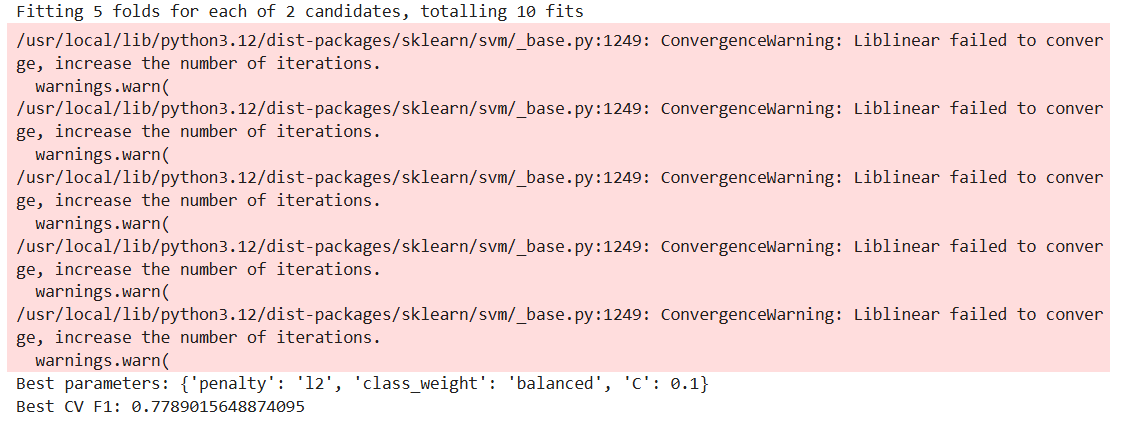

In [77]:
# Score on Validation set

# best_svc = grid_search.best_estimator_
# y_pred = best_svm.predict(X_val_ss)
# f1 = f1_score(y_val, y_pred, average='macro')
# print("F1 Score: ", f1)

# F1 Score:  0.78588151277501

### Prediction

In [78]:
# svc_test = LinearSVC(C=0.1, class_weight= "balanced",loss = "squared_hinge", penalty="l2")
# svc_test.fit(train_ss, y_full_train)
# 0.77465

In [79]:
# svc_preds = svc_test.predict(test_copy_ss)
# svc_preds

# LightGBM Model

In [80]:
# lgbm = lgb.LGBMClassifier()

In [81]:
# lgbm.fit(X_train_mm, y_train)
# score_lgbm_mm = lgbm.predict(X_val_mm)
# f1 = f1_score(y_val, score_lgbm_mm, average='macro')
# print("F1 Score:", f1)

In [82]:
# lgbm.fit(X_train_ss, y_train)
# score_lgbm_ss = lgbm.predict(X_val_ss)
# f1 = f1_score(y_val, score_lgbm_ss, average='macro')
# print("F1 Score:", f1)

### Hyperparameter Tuning

In [83]:
# lgbm_new = lgb.LGBMClassifier()

In [84]:
# param_dist = {
#     'learning_rate': [0.01, 0.05],
#     'max_depth':     [30, 60],
#     'n_estimators':  [200, 300]
# }



# random_search = RandomizedSearchCV(
#     estimator=lgbm_new,
#     param_grid=param_dist,
#     cv=3,
#     scoring="f1_macro",
#     n_jobs=-1,
#     random_state= 42,
#     n_iter = 6
# )

In [85]:
# random_search.fit(X_train_ss, y_train)
# print("Best parameters:", random_search.best_params_)
# print("Best CV F1:", random_search.best_score_)

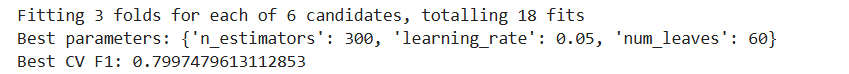

In [86]:
# Score on Validation set

# best_lgbm = random_search.best_estimator_
# best_lgbm.fit(X_train_ss, y_train)
# y_pred = best_lgbm.predict(X_val_ss)
# f1 = f1_score(y_val, y_pred, average='macro')
# print("F1 Score: ", f1)

# F1 Score:  0.7997479613112853

### Prediction

In [87]:
lgbm_test = lgb.LGBMClassifier(n_estimators = 300, learning_rate = 0.05, num_leaves = 60, random_state=42)
lgbm_test.fit(train_ss, y_full_train)
# 0.80117 

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 4.825464 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 661701
[LightGBM] [Info] Number of data points in the train set: 197999, number of used features: 4331
[LightGBM] [Info] Start training from score -0.550556
[LightGBM] [Info] Start training from score -2.520811
[LightGBM] [Info] Start training from score -1.154056
[LightGBM] [Info] Start training from score -3.589166


LGBMClassifier(learning_rate=0.05, n_estimators=300, num_leaves=60,
               random_state=42)

In [88]:
lgbm_preds = lgbm_test.predict(test_copy_ss)
lgbm_preds

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


array([2, 2, 0, ..., 0, 0, 2])

# XGBoost Model

In [89]:
# xgb = XGBClassifier()

In [90]:
# xgb.fit(X_train_mm, y_train)
# score_xgb_mm = xgb.predict(X_val_mm)
# f1 = f1_score(y_val, score_xgb_mm, average='macro')
# print("F1:", f1)

In [91]:
# xgb.fit(X_train_ss, y_train)
# score_xgb_ss = xgb.predict(X_val_ss)
# f1 = f1_score(y_val, score_xgb_ss, average='macro')
# print("F1:", f1)

### Hyperparameter Tuning

In [92]:
# xgb_new = XGBClassifier()

In [93]:
# param_dist = {
#     'learning_rate': [0.5, 0.1],
#     'max_depth':     [5, 10],
#     'n_estimators':  [200, 500]
# }



# random_search = RandomizedSearchCV(
#     estimator=xgb_new,
#     param_grid=param_dist,
#     cv=3,
#     scoring="f1_macro",
#     n_jobs=-1,
#     random_state= 42,
#     n_iter = 6
# )

In [94]:
# random_search.fit(X_train_ss, y_train)
# print("Best parameters:", random_search.best_params_)
# print("Best CV F1:", random_search.best_score_)

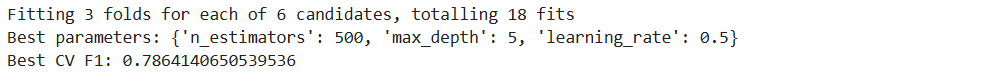

In [95]:
# Score on Validation

# best_xgb = random_search.best_estimator_
# best_xgb.fit(X_train_ss, y_train)
# y_pred = best_xgb.predict(X_val_ss)
# f1 = f1_score(y_val, y_pred, average='macro')
# print("F1 Score: ", f1)

### Prediction

In [96]:
# xgb_test = XGBClassifier(n_estimators= 500, max_depth = 5, learning_rate= 0.5)
# xgb_test.fit(train_ss, y_full_train)
# 0.78805

In [97]:
# xgb_preds = xgb_test.predict(test_copy_ss)
# xgb_preds

# Submission

In [98]:
sample_sub['label'] = lgbm_preds
sample_sub.to_csv("submission.csv", index = False)

# Comparison of Models

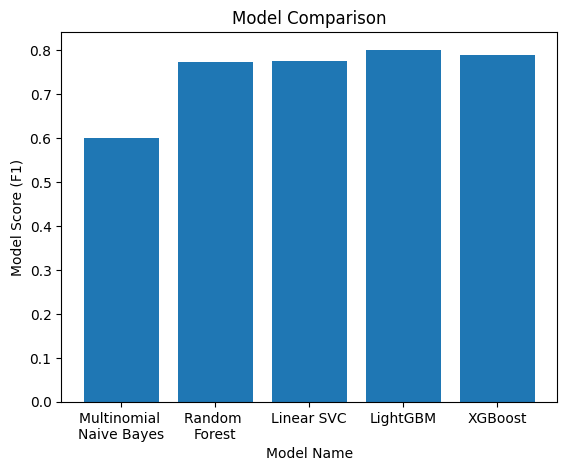

In [99]:
model_score = [0.60098, 0.77409, 0.77465, 0.80146 , 0.78805]
model_name = ["Multinomial \nNaive Bayes", "Random \nForest", "Linear SVC", "LightGBM", "XGBoost"]

plt.bar(model_name, model_score)
plt.title("Model Comparison")
plt.xlabel("Model Name")
plt.ylabel("Model Score (F1)")
plt.show()

#### Insight
1. Multinomial Naive Bayes performed the weakest with score 0.60098
2. Random Forest and Linear SVC performed similar with score 0.77409 and 0.77465 respectively
3. XGBoost performed the second best with score 0.78805
4. LightGBM performed the best with score 0.80117